# Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón
## Contexto del Problema
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados.

Se cuenta con dos variables de entrada:

* Puntaje Crediticio (Normalizado de 0 a 1).

* Ratio de Ahorro (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un Perceptrón Simple en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

## Paso 1: Preparación del Entorno
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

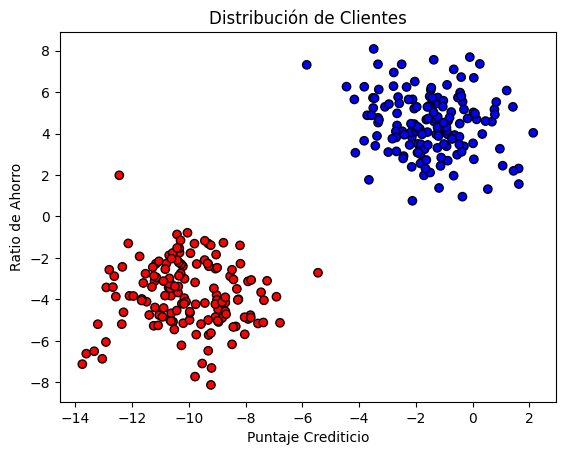

In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.5, random_state=1)

# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

## Paso 2: Definición de la Arquitectura (Misión del Alumno)
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**Guía Técnica:**

* Usa una capa Dense.

* Como es un Perceptrón de una sola capa, units debe ser igual a 1.

* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [2]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
model = Sequential([
    # 1 neurona, 2 entradas (Puntaje y Ratio), activación sigmoide para probabilidad
    Dense(units=1, input_shape=(2,), activation='sigmoid')
])
# ------------

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Sequential:
Define que los datos fluyen en una sola dirección, de la entrada a la salida.
## Dense:
Crea una capa donde todas las entradas están conectadas a la neurona.
## units=1:
Es un Perceptrón Simple, por eso tiene una sola unidad de procesamiento (una sola neurona).
## input_shape=(2,):
Representa las dos "dendritas" o variables: Puntaje Crediticio y Ratio de Ahorro.
## activation='sigmoid':
Esla Función de Activación.
Transforma la suma de datos en una probabilidad entre 0 y 1 para decidirsi aprueba el crédito o no.

## Paso 3: Compilación del Sistema
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

**Ayuda Sugerida:**

* Para clasificación binaria, la pérdida estándar es binary_crossentropy.

* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

In [3]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# ------

## optimizer=SGD:
Es el "descenso de gradiente". Es el algoritmo que ajusta los pesos para bajar la montaña del error.
## learning_rate=0.1:
Es la Tasa de Aprendizaje. Define que el modelo dé pasos de tamaño 0.1 para no pasarse del punto óptimo pero tampoco tardar demasiado.
## loss='binary_crossentropy':
La fórmula matemática que mide qué tan lejos está la predicción (0 o 1) de la realidad

## Paso 4: Entrenamiento y Regularización
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**Instrucciones:**

* Ejecuta el método .fit().

* Prueba configurar el entrenamiento con 50 épocas.

Este comando inicia el proceso de recalibración de **pesos**. El modelo predice, calcula el error y ajusta sus pesos $w$ y su sesgo $b$ repetidamente hasta que la precisión llega al máximo

In [4]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
history = model.fit(X, y, epochs=50, verbose=1)
# --

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5500 - loss: 2.4253       
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0696 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0425 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0318 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0262 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0226 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0200 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0180 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0165 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0152 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0142 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accu

### Epoch 1/50:
 Significa que es la primera vez (de 50) que la red neuronal ve todos los datos para aprender de ellos.
### 10/10:
 El modelo dividió los 300 clientes en 10 grupos (batches). Procesó los 10 grupos para completar una época.
### Accuracy (Precisión):
  *  En la Epoch 1, tenemos 0.8100 (81%). El modelo todavía estaba "calibrando sus sinapsis".
  *  En la Epoch 2, saltó a 1.0000 (100%). Esto significa que el Perceptrón encontró rápidamente la línea recta que separa a los clientes de bajo riesgo de los de alto riesgo.
Loss (Pérdida):
### Es el error del modelo.
cómo bajó de 0.5479 en la primera época a 0.0054 en la última.
Cuanto más cerca de cero está la pérdida,
más "segura" está la neurona de sus decisiones

## Paso 5: Evaluación de Resultados
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step


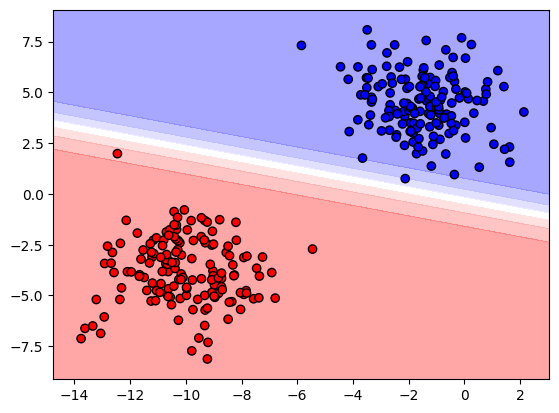

In [ ]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## Desafíos Extra
**Impacto del Sesgo:** Si imprimes los pesos del modelo con model.get_weights(), ¿cuál es el valor del Bias?

¿Qué pasaría si fuera cero?

**Regularización:** Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.

¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?

**No Linealidad:** Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.

## RESPUESTA

## Impacto del Sesgo (Bias):

¿Cuál es su valor? Lo verás al ejecutar model.get_weights()[1].




In [5]:
model.get_weights()[1]

array([-0.43754563], dtype=float32)

## ¿Qué pasaría si fuera cero?
  Bias permite que la frontera de decisión se desplace. Si fuera cero, la línea estaría obligada a pasar por el origen (0,0), lo que probablemente no encajaría con tus datos de clientes

## Regularización:
Regresa al Paso 2 e intenta agregar **kernel_regularizer='l2'** dentro de la capa Dense.



La regularización es el mecanismo que garantiza que el conocimiento de la neurona sea aplicable a situaciones reales y no una mera memorización de ruidos

### Evita el sobreajuste (Overfitting):
La **regularización L2** (también llamada Ridge) penaliza los pesos muy grandes sumando el cuadrado de sus valores a la función de pérdida.
### Pesos Pequeños:
 Esto obliga al sistema a mantener todos los pesos pequeños, lo que hace que el modelo sea más estable y suave
### Frontera "Conservadora":
  Como los pesos no pueden ser gigantes, la línea que separa a los clientes no "salta" ante cualquier dato extraño, sino que busca una tendencia más general y robusta

In [9]:

from tensorflow.keras import regularizers

model = Sequential([
    # Agregamos kernel_regularizer dentro de la capa Dense
    Dense(
        units=1,
        input_shape=(2,),
        activation='sigmoid',
        kernel_regularizer=regularizers.l2(0.01) # 0.01 es la fuerza de la penalización
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(X, y, epochs=30, verbose=1)

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step


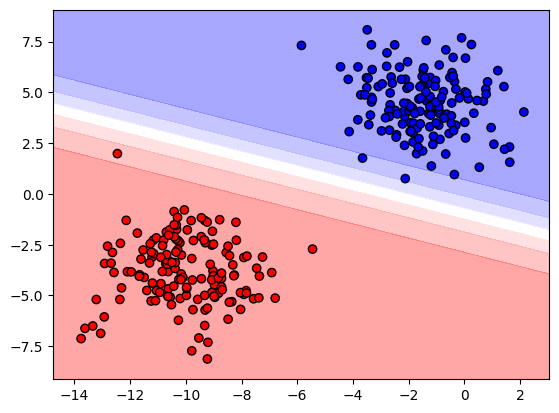

In [15]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

### ¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?
En la frontera de decisión se vuelve más "conservadora" y estable ante ruidos

## No Linealidad (El caso make_moons):
¿Es capaz de separarlos? No.
* El Perceptrón simple es un clasificador lineal; solo puede trazar líneas rectas.

## Diferencia Geométrica: Círculo vs. Diamante

## L2 (Círculo):
La restricción se representa como un círculo. Es ideal para redes profundas porque previene el sobreajuste de forma estable.
## L1 (Diamante):
  La restricción es un diamante. Esta técnica (Lasso) es más radical y puede llevar los pesos directamente a cero, eliminando variables que no sirven

### PROBAMOS REGULARIZACION L1

L1 tiene la capacidad de simplificar el modelo eliminando las conexiones que no aportan información significativa.

In [16]:
from tensorflow.keras import regularizers

model = Sequential([
    Dense(
        units=1,
        input_shape=(2,),
        activation='sigmoid',
        # Ahora usamos L1 (Lasso)
        kernel_regularizer=regularizers.l1(0.01)
    )
])

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step


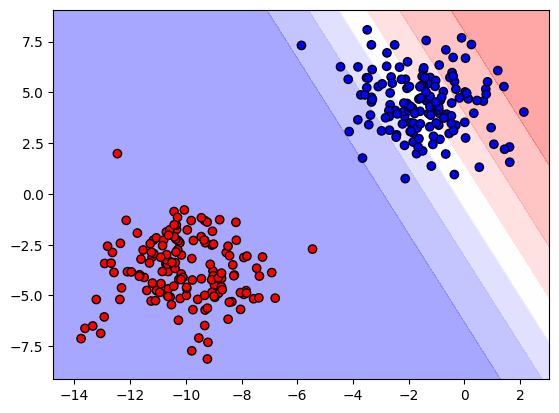

In [17]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## Analizemos el gráfico con la Regularización L1 (Lasso)

### Selección de Variables (Sparsity):
Al usar L1, el sistema aplica una penalización constante que empuja los pesos hacia el cero absoluto. Si nos fijamos , la línea ahora es más "empinada". Esto sugiere que la neurona le está dando mucha más importancia a una variable y casi nada a la otra.
### Efecto "Diamante":
  Geométricamente, el punto óptimo "tocó" una de las esquinas del diamante de restricción de L1. Por eso la frontera de decisión se vuelve tan dependiente de un solo eje.
### Modelo Simplificado:
  A diferencia de L2 (que mantiene todos los pesos aunque sean chiquitos), L1 "apaga" las conexiones que considera redundantes.
  El modelo ahora es más fácil de interpretar: el banco podría decir "para este grupo de clientes, solo nos importa el puntaje y no tanto cuánto ahorran".